# 2D Average of equatorial particles

In this notebook, we will average the equatorial particles to get a 2D average of the equatorial particles.
Since we have the rotation around the centroid of the vesicle, we will align the particles at particle centres, apply the rotation, and then average them to produce a 2D average.

### Step 0: Load in libraries


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import mrcfile
import pickle
import os
import cv2
import scipy.ndimage as ndimage
import scipy.ndimage.filters as filters
import scipy.ndimage.morphology as morphology
import scipy.ndimage.interpolation as interpolation
import scipy.ndimage.measurements as measurements
import scipy.ndimage.filters as filters
import scipy.ndimage.morphology as morphology
import scipy.ndimage.interpolation as interpolation
import scipy.ndimage.measurements as measurements
import pytorch3d.transforms as transforms

from cryosparc.dataset import Dataset

### Step 1: Load in the dataset

We will load in the dataset with the equatorial particles with their predicted angles.

In [2]:
# particle_dataset = Dataset.load('/Users/gerdbizi/Desktop/Rubinstein Lab/rotation_debugging_495/angle_estimated_equatorial_particles_small.cs')
particle_dataset = Dataset.load('/Users/gerdbizi/Desktop/Rubinstein Lab/rotation_debugging_495/angle_estimated_equatorial_particles_rotation_matrix_big.cs')
mrc_file_dir = '/Users/gerdbizi/Desktop/Rubinstein Lab/ryan_images'

Let's display three random particles from the dataset, and also apply the rotation to the particle.

We'll also need our functions for converting from axis-angle to Euler angles.

These functions were taken from https://github.com/asarnow/pyem/blob/master/pyem/geom/convert.py

In [3]:
def aa2quat(ax, theta=None):
    if theta is None:
        theta = np.linalg.norm(ax)
        if theta != 0:
            ax = ax / theta
    q = np.zeros(4, dtype=ax.dtype)
    q[0] = np.cos(theta / 2)
    q[1:] = ax * np.sin(theta / 2)
    return q

def quat2rot(q):
    n = np.sum(q**2)
    s = 0 if n == 0 else 2 / n
    wx = s * q[0] * q[1]
    wy = s * q[0] * q[2]
    wz = s * q[0] * q[3]
    xx = s * q[1] * q[1]
    xy = s * q[1] * q[2]
    xz = s * q[1] * q[3]
    yy = s * q[2] * q[2]
    yz = s * q[2] * q[3]
    zz = s * q[3] * q[3]
    r = np.array([[1 - (yy + zz), xy + wz,       xz - wy],
                  [xy - wz,       1 - (xx + zz), yz + wx],
                  [xz + wy,       yz - wx,       1 - (xx + yy)]], dtype=q.dtype)
    return r

def rot2euler(r):
    """Decompose rotation matrix into Euler angles"""
    # assert(isrotation(r))
    # Shoemake rotation matrix decomposition algorithm with same conventions as Relion.
    epsilon = np.finfo(np.double).eps
    abs_sb = np.sqrt(r[0, 2] ** 2 + r[1, 2] ** 2)
    if abs_sb > 16 * epsilon:
        gamma = np.arctan2(r[1, 2], -r[0, 2])
        alpha = np.arctan2(r[2, 1], r[2, 0])
        if np.abs(np.sin(gamma)) < epsilon:
            sign_sb = np.sign(-r[0, 2]) / np.cos(gamma)
        else:
            sign_sb = np.sign(r[1, 2]) if np.sin(gamma) > 0 else -np.sign(r[1, 2])
        beta = np.arctan2(sign_sb * abs_sb, r[2, 2])
    else:
        if np.sign(r[2, 2]) > 0:
            alpha = 0
            beta = 0
            gamma = np.arctan2(-r[1, 0], r[0, 0])
        else:
            alpha = 0
            beta = np.pi
            gamma = np.arctan2(r[1, 0], -r[0, 0])
    return alpha, beta, gamma

In [4]:
import torch
import torch.nn.functional as F
import numpy as np
from scipy import ndimage
import mrcfile

# Initialize the sum and count
sum_image = None
count = 0
batch = []
target_size = 710  # Define target size for all particles

for i, particle in enumerate(particle_dataset.rows()[:10000]):
    # Load and preprocess particle
    particle_path = os.path.join(mrc_file_dir, particle['blob/path'])
    particle_idx = particle['blob/idx']
    particle_mrc = mrcfile.open(particle_path, mode='r').data

    # If 2 dimensions, make it 1 x n x m
    if len(particle_mrc.shape) == 2:
        particle_mrc = particle_mrc[np.newaxis, :, :]

    particle_mrc = particle_mrc[particle_idx]

    mask = np.ones_like(particle_mrc)

    # Calculate rotation angle
    axis_angle = particle['alignments3D/pose']
    q = aa2quat(axis_angle)
    r = quat2rot(q)
    euler_angles = rot2euler(r)
    alpha_rad = -(euler_angles[2] + np.pi/2)
    alpha_deg = np.rad2deg(alpha_rad)
    
    # Rotate particle
    try:
        rotated_particle = ndimage.rotate(particle_mrc, alpha_deg, reshape=True)
        rotated_mask = ndimage.rotate(mask, alpha_deg, reshape=True)
    except ValueError:
        print(f"Error rotating particle {particle_idx}")
        print(f"Particle path: {particle_path}")
        print(f"Particle mrc shape: {particle_mrc.shape}")
        continue
    
    rotated_particle = np.where(rotated_mask == 1, rotated_particle, 0.0)

    # Calculate padding sizes
    pad_height = target_size - rotated_particle.shape[0]
    pad_width = target_size - rotated_particle.shape[1]
    
    # Ensure even padding on both sides
    top_pad = pad_height // 2
    bottom_pad = pad_height - top_pad
    left_pad = pad_width // 2
    right_pad = pad_width - left_pad
    
    # Pad the particle to exact target size
    final_particle = np.pad(
        rotated_particle,
        ((top_pad, bottom_pad), (left_pad, right_pad)),
        mode='constant',
        constant_values=0
    )
    
    batch.append(final_particle)
    print(f"Processed particle {i+1} of {len(particle_dataset.rows())}")

# Convert list of particles to numpy array and calculate average
batch_array = np.array(batch)
average_image = np.mean(batch_array, axis=0)


Processed particle 1 of 69304
Processed particle 2 of 69304
Processed particle 3 of 69304
Processed particle 4 of 69304
Processed particle 5 of 69304
Processed particle 6 of 69304
Processed particle 7 of 69304
Processed particle 8 of 69304
Processed particle 9 of 69304
Processed particle 10 of 69304
Processed particle 11 of 69304
Processed particle 12 of 69304
Processed particle 13 of 69304
Processed particle 14 of 69304
Processed particle 15 of 69304
Processed particle 16 of 69304
Processed particle 17 of 69304
Processed particle 18 of 69304
Processed particle 19 of 69304
Processed particle 20 of 69304
Processed particle 21 of 69304
Processed particle 22 of 69304
Processed particle 23 of 69304
Processed particle 24 of 69304
Processed particle 25 of 69304
Processed particle 26 of 69304
Processed particle 27 of 69304
Processed particle 28 of 69304
Processed particle 29 of 69304
Processed particle 30 of 69304
Processed particle 31 of 69304
Processed particle 32 of 69304
Processed particl

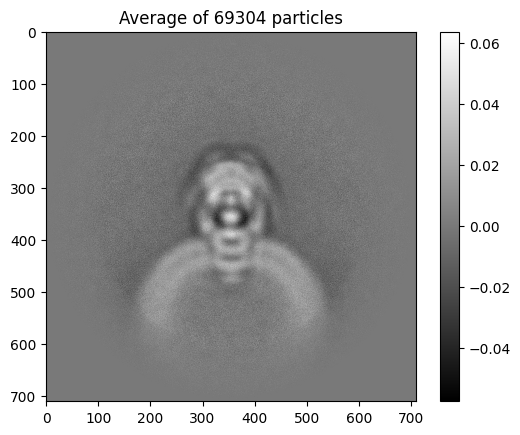

In [5]:
plt.imshow(average_image, cmap='gray')
plt.title(f'Average of 10000 particles')
plt.colorbar()
plt.show()

In [14]:
# Save the average image
mrcfile.write('average_image.mrc', average_image, overwrite=True)

In [7]:
import matplotlib.pyplot as plt

# Create a figure and axis (adjust 'figsize' as needed)
fig, ax = plt.subplots(figsize=(7.1, 7.1))
ax.imshow(average_image, cmap='gray')

# Remove axes from the figure
ax.axis('off')

# Adjust layout to remove extra margins and white borders
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

# Save the image with high DPI (600 dpi) and no extra padding or borders.
plt.savefig('average_image_highdpi.png', dpi=1000, bbox_inches='tight', pad_inches=0)
plt.close(fig)